# Benchmarking Tabular Explainer
To benchmark `shapiq`'s `TabularExplainer` we run it against the equivalent explainers of the shap library. For comparing different approximators and imputer strategies we run both the `shapiq` and the `shap` versions against the exact calculation of Shapley values.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import shap
import shapiq

from shapiq_student.explainer.knn.base import interaction_values_to_array

## Preparing Datasets and models
We use the `california_housing` and the `bike_sharing` datasets for the benchmark as they are comparably small datasets (so the exact Shapley values can be computed in reasonable time). Still they are realistic, real world data sets.
The values are scaled to a range from -1 to 1 and split up in training and test data (80:20).
We use a regression model (scikit-learn's`DecisionTreeRegressor`) to be explained in the benchmark.

In [2]:
bike_tree = shapiq.games.benchmark.setup.GameBenchmarkSetup(
    dataset_name="bike_sharing", model_name="decision_tree"
)
house_tree = shapiq.games.benchmark.setup.GameBenchmarkSetup(
    dataset_name="california_housing", model_name="decision_tree"
)
bike_x_train = bike_tree.x_train
bike_x_test = bike_tree.x_test
bike_y_train = bike_tree.y_train
bike_y_test = bike_tree.y_test

house_x_train = house_tree.x_train
house_x_test = house_tree.x_test
house_y_train = house_tree.y_train
house_y_test = house_tree.y_test

## Imputation
As the performance concerning speed as well as quality of an approximator depends strongly on the used imputer, we are going to use different imputers for comparison.
On the other hand the performance of an approximator depends on the number of iterations so we are going to run the test on the same amount for each approximator.
As baseline explainer, shapiq's KernelExplainer is used on an comparably big budget of 256 respectively 1000.

In [3]:
sample_size = 200
# The number of samples to draw from the conditional background data for the imputation.

conditional_budget = np.arange(2, 101, 1)
# The number of coalitions to sample per each point in `data` for training the generative model.

random_state = 42

test_point_budget = 50

n_jobs = 18

## Running the Explainers


In [4]:
kern_house = shapiq.approximator.KernelSHAP(len(house_x_train[0]))
kern_bike = shapiq.approximator.KernelSHAP(len(bike_x_train[0]))

# initialize approximators:
svarm_house = shapiq.approximator.SVARM(
    n=len(house_x_train[0]), index="SV", random_state=random_state
)
svarm_bike = shapiq.approximator.SVARM(
    n=len(bike_x_train[0]), index="SV", random_state=random_state
)

perm_house = shapiq.approximator.PermutationSamplingSV(
    n=len(house_x_train[0]), random_state=random_state
)
perm_bike = shapiq.approximator.PermutationSamplingSV(
    n=len(bike_x_train[0]), random_state=random_state
)


# initialize shapiq explainers:

house_base = shapiq.TabularExplainer(
    model=house_tree.model,
    data=house_tree.x_train,
    class_index=None,
    imputer="marginal",
    approximator=kern_house,
    index="SV",
    max_order=1,
    random_state=random_state,
    verbose=False,
    sample_size=10 * sample_size,
    joint_marginal_distribution=False,
    normalize=False,
)
bike_base = shapiq.TabularExplainer(
    model=bike_tree.model,
    data=bike_tree.x_train,
    class_index=None,
    imputer="marginal",
    approximator=kern_bike,
    index="SV",
    max_order=1,
    random_state=random_state,
    verbose=False,
    sample_size=10 * sample_size,
    joint_marginal_distribution=False,
    normalize=False,
)
house_tree_kernel = shapiq.TabularExplainer(
    model=house_tree.model,
    data=house_tree.x_train,
    class_index=None,
    imputer="marginal",
    approximator=kern_house,
    index="SV",
    max_order=1,
    random_state=random_state,
    verbose=False,
    sample_size=sample_size,
    joint_marginal_distribution=False,
    normalize=False,
)
bike_tree_kernel = shapiq.TabularExplainer(
    model=bike_tree.model,
    data=bike_tree.x_train,
    class_index=None,
    imputer="marginal",
    approximator=kern_bike,
    index="SV",
    max_order=1,
    random_state=random_state,
    verbose=False,
    sample_size=sample_size,
    joint_marginal_distribution=False,
    normalize=False,
)
house_tree_svarm = shapiq.TabularExplainer(
    model=house_tree.model,
    data=house_tree.x_train,
    class_index=None,
    imputer="marginal",
    approximator=svarm_house,
    index="SV",
    max_order=1,
    random_state=random_state,
    verbose=False,
    sample_size=sample_size,
    joint_marginal_distribution=False,
    normalize=False,
)
bike_tree_svarm = shapiq.TabularExplainer(
    model=bike_tree.model,
    data=bike_tree.x_train,
    class_index=None,
    imputer="marginal",
    approximator=svarm_bike,
    index="SV",
    max_order=1,
    random_state=random_state,
    verbose=False,
    sample_size=sample_size,
    joint_marginal_distribution=False,
    normalize=False,
)
house_tree_perm = shapiq.TabularExplainer(
    model=house_tree.model,
    data=house_tree.x_train,
    class_index=None,
    imputer="marginal",
    approximator=perm_house,
    index="SV",
    max_order=1,
    random_state=random_state,
    verbose=False,
    sample_size=sample_size,
    joint_marginal_distribution=False,
    normalize=False,
)
bike_tree_perm = shapiq.TabularExplainer(
    model=bike_tree.model,
    data=bike_tree.x_train,
    class_index=None,
    imputer="marginal",
    approximator=perm_bike,
    index="SV",
    max_order=1,
    random_state=random_state,
    verbose=False,
    sample_size=sample_size,
    joint_marginal_distribution=False,
    normalize=False,
)


# initialize accumulators:

h_base_results = []
b_base_results = []

h_shap_kern_results = []
h_shap_perm_results = []
b_shap_kern_results = []
b_shap_perm_results = []

h_shapiq_kern_results = []
h_shapiq_svarm_results = []
h_shapiq_perm_results = []
b_shapiq_kern_results = []
b_shapiq_svarm_results = []
b_shapiq_perm_results = []


# initialize and run shap explainers:

for k in range(len(conditional_budget)):
    house_tree_shap_kern = shap.explainers.Kernel(
        model=house_tree.predict_function,
        data=shap.sample(house_tree.x_train, conditional_budget[k]),
        seed=random_state,
    )
    bike_tree_shap_kern = shap.explainers.Kernel(
        model=bike_tree.predict_function,
        data=shap.sample(bike_tree.x_train, conditional_budget[k]),
        seed=random_state,
    )

    house_tree_shap_perm = shap.explainers.Permutation(
        model=house_tree.predict_function,
        masker=shap.maskers.Independent(
            data=shap.sample(house_tree.x_train, sample_size), max_samples=conditional_budget[k]
        ),
        seed=random_state,
    )

    bike_tree_shap_perm = shap.explainers.Permutation(
        model=bike_tree.predict_function,
        masker=shap.maskers.Independent(
            data=shap.sample(bike_tree.x_train, sample_size), max_samples=conditional_budget[k]
        ),
        seed=random_state,
    )

    h_t_s_p_expl = house_tree_shap_perm(house_x_test[:test_point_budget], silent=True)
    h_shap_perm_results.append(h_t_s_p_expl)

    b_t_s_p_expl = bike_tree_shap_perm(bike_x_test[:test_point_budget], silent=True)
    b_shap_perm_results.append(b_t_s_p_expl)

    h_t_s_k_expl = house_tree_shap_kern(house_x_test[:test_point_budget], silent=True)
    h_shap_kern_results.append(h_t_s_k_expl)

    b_t_s_k_expl = bike_tree_shap_kern(bike_x_test[:test_point_budget], silent=True)
    b_shap_kern_results.append(b_t_s_k_expl)


# run baseline explainers:

h_base_expl = house_base.explain_X(
    X=house_x_test[:test_point_budget],
    n_jobs=n_jobs,
    budget=256,
    random_state=random_state,
    verbose=False,
)
h_base_results.append(h_base_expl)
h_base_results = h_base_results[0]

b_base_expl = bike_base.explain_X(
    X=bike_x_test[:test_point_budget],
    n_jobs=n_jobs,
    budget=1000,
    random_state=random_state,
    verbose=False,
)
b_base_results.append(b_base_expl)
b_base_results = b_base_results[0]


# run shapiq explainers:

for i in range(len(conditional_budget)):
    h_t_k_expl = house_tree_kernel.explain_X(
        X=house_x_test[:test_point_budget],
        n_jobs=n_jobs,
        budget=conditional_budget[i],
        random_state=random_state,
        verbose=False,
    )
    h_shapiq_kern_results.append(h_t_k_expl)
    b_t_k_expl = bike_tree_kernel.explain_X(
        X=bike_x_test[:test_point_budget],
        n_jobs=n_jobs,
        budget=conditional_budget[i],
        random_state=random_state,
        verbose=False,
    )
    b_shapiq_kern_results.append(b_t_k_expl)
    h_t_s_expl = house_tree_svarm.explain_X(
        X=house_x_test[:test_point_budget],
        n_jobs=n_jobs,
        budget=conditional_budget[i],
        random_state=random_state,
        verbose=False,
    )
    h_shapiq_svarm_results.append(h_t_s_expl)
    b_t_s_expl = bike_tree_svarm.explain_X(
        X=bike_x_test[:test_point_budget],
        n_jobs=n_jobs,
        budget=conditional_budget[i],
        random_state=random_state,
        verbose=False,
    )
    b_shapiq_svarm_results.append(b_t_s_expl)
    h_t_p_expl = house_tree_perm.explain_X(
        X=house_x_test[:test_point_budget],
        n_jobs=n_jobs,
        budget=conditional_budget[i],
        random_state=random_state,
        verbose=False,
    )
    h_shapiq_perm_results.append(h_t_p_expl)
    b_t_p_expl = bike_tree_perm.explain_X(
        X=bike_x_test[:test_point_budget],
        n_jobs=n_jobs,
        budget=conditional_budget[i],
        random_state=random_state,
        verbose=False,
    )
    b_shapiq_perm_results.append(b_t_p_expl)

## Calculating the L1 and L2 Difference to Baseline
To compare the explainers we use the average L1 and L2 differences to the Shapley values of the baseline explainer.
We display them on a log scale to make the effects for greater conditional budgets visible.

In [5]:
# Function to calculate the average L1 Difference of shap explanations where b is the shapiq baseline explanation
def shap_average_l1_diffs(x, b) -> np.array:
    sums_of_budgets = np.zeros(len(conditional_budget))
    for o in range(len(conditional_budget)):
        for m in range(test_point_budget):
            sum_all_points = 0
            for n in range(len(house_x_test[0])):
                diff_point = abs(((interaction_values_to_array(b[m]))[n]) - ((x[o]).values[m, n]))
                sum_all_points = sum_all_points + diff_point
            sum_budget = sum_all_points / test_point_budget
        sums_of_budgets[o] = sum_budget
    return sums_of_budgets


# Function to calculate the average L1 Difference of shapiq explanations where b is the shapiq baseline explanation
def shapiq_average_l1_diffs(x, b) -> np.array:
    sums_of_budgets = np.zeros(len(conditional_budget))
    for o in range(len(conditional_budget)):
        for m in range(test_point_budget):
            sum_all_points = 0
            for n in range(len(house_x_test[0])):
                diff_point = abs(
                    (interaction_values_to_array((b[m]))[n])
                    - ((interaction_values_to_array(x[o][m]))[n])
                )
                sum_all_points = sum_all_points + diff_point
            sum_budget = sum_all_points / test_point_budget
        sums_of_budgets[o] = sum_budget
    return sums_of_budgets


# Function to calculate the average L2 Difference of shap explanations where b is the shapiq baseline explanation
def shap_average_l2_diffs(x, b) -> np.array:
    sums_of_budgets = np.zeros(len(conditional_budget))
    for o in range(len(conditional_budget)):
        for m in range(test_point_budget):
            sum_all_points = 0
            reference = interaction_values_to_array(b[m])
            actual = x[o].values[m]
            sum_all_points = np.sqrt(np.sum((reference - actual) ** 2))
            sum_budget = sum_all_points / test_point_budget
        sums_of_budgets[o] = sum_budget
    return sums_of_budgets


# Function to calculate the average L2 Difference of shapiq explanations where b is the shapiq baseline explanation
def shapiq_average_l2_diffs(x, b) -> np.array:
    sums_of_budgets = np.zeros(len(conditional_budget))
    for o in range(len(conditional_budget)):
        for m in range(test_point_budget):
            sum_all_points = 0
            for n in range(len(house_x_test[0])):
                diff_point = (
                    ((interaction_values_to_array(b[m]))[n])
                    - ((interaction_values_to_array(x[o][m]))[n])
                ) ** 2
                sum_all_points = sum_all_points + diff_point
            sum_budget = (np.sqrt(sum_all_points)) / test_point_budget
        sums_of_budgets[o] = sum_budget
    return sums_of_budgets


h_shap_kern_average_l1 = shap_average_l1_diffs(x=h_shap_kern_results, b=h_base_results)

h_shap_perm_average_l1 = shap_average_l1_diffs(x=h_shap_perm_results, b=h_base_results)

h_shapiq_kern_average_l1 = shapiq_average_l1_diffs(x=h_shapiq_kern_results, b=h_base_results)

h_shapiq_svarm_average_l1 = shapiq_average_l1_diffs(x=h_shapiq_svarm_results, b=h_base_results)

h_shapiq_perm_average_l1 = shapiq_average_l1_diffs(x=h_shapiq_perm_results, b=h_base_results)

###########################################################

h_shap_kern_average_l2 = shap_average_l2_diffs(x=h_shap_kern_results, b=h_base_results)

h_shap_perm_average_l2 = shap_average_l2_diffs(x=h_shap_perm_results, b=h_base_results)

h_shapiq_kern_average_l2 = shapiq_average_l2_diffs(x=h_shapiq_kern_results, b=h_base_results)

h_shapiq_svarm_average_l2 = shapiq_average_l2_diffs(x=h_shapiq_svarm_results, b=h_base_results)

h_shapiq_perm_average_l2 = shapiq_average_l2_diffs(x=h_shapiq_perm_results, b=h_base_results)

####################################################################

b_shap_kern_average_l1 = shap_average_l1_diffs(x=b_shap_kern_results, b=b_base_results)

b_shap_perm_average_l1 = shap_average_l1_diffs(x=b_shap_perm_results, b=b_base_results)

b_shapiq_kern_average_l1 = shapiq_average_l1_diffs(x=b_shapiq_kern_results, b=b_base_results)

b_shapiq_svarm_average_l1 = shapiq_average_l1_diffs(x=b_shapiq_svarm_results, b=b_base_results)

b_shapiq_perm_average_l1 = shapiq_average_l1_diffs(x=b_shapiq_perm_results, b=b_base_results)

####################################################################

b_shap_kern_average_l2 = shap_average_l2_diffs(x=b_shap_kern_results, b=b_base_results)

b_shap_perm_average_l2 = shap_average_l2_diffs(x=b_shap_perm_results, b=b_base_results)

b_shapiq_kern_average_l2 = shapiq_average_l2_diffs(x=b_shapiq_kern_results, b=b_base_results)

b_shapiq_svarm_average_l2 = shapiq_average_l2_diffs(x=b_shapiq_svarm_results, b=b_base_results)

b_shapiq_perm_average_l2 = shapiq_average_l2_diffs(x=b_shapiq_perm_results, b=b_base_results)

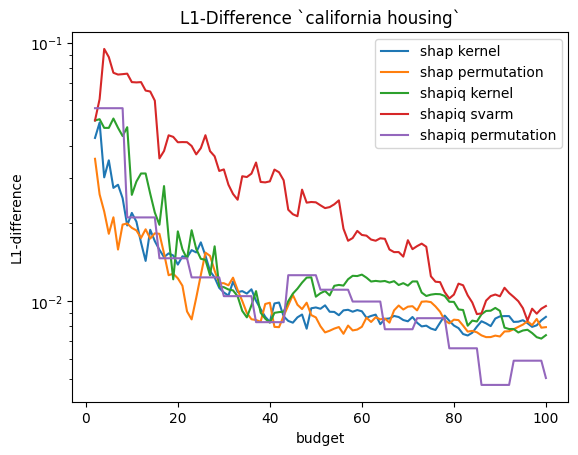

In [6]:
plt.plot(conditional_budget, h_shap_kern_average_l1, label="shap kernel")
plt.plot(conditional_budget, h_shap_perm_average_l1, label="shap permutation")
plt.plot(conditional_budget, h_shapiq_kern_average_l1, label="shapiq kernel")
plt.plot(conditional_budget, h_shapiq_svarm_average_l1, label="shapiq svarm")
plt.plot(conditional_budget, h_shapiq_perm_average_l1, label="shapiq permutation")

plt.yscale("log")
plt.xlabel("budget")
plt.ylabel("L1-difference")
plt.title("L1-Difference `california housing`")
plt.legend();

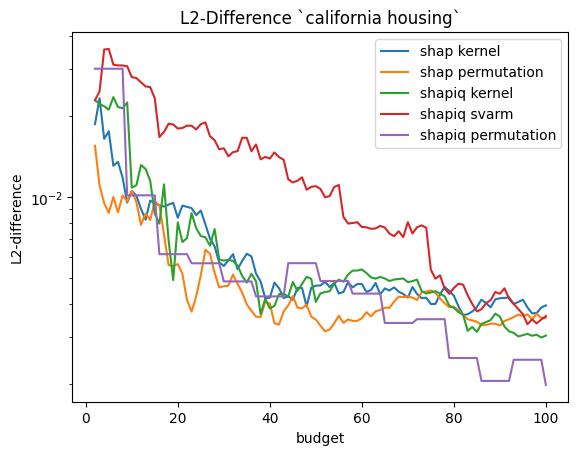

In [7]:
plt.plot(conditional_budget, h_shap_kern_average_l2, label="shap kernel")
plt.plot(conditional_budget, h_shap_perm_average_l2, label="shap permutation")
plt.plot(conditional_budget, h_shapiq_kern_average_l2, label="shapiq kernel")
plt.plot(conditional_budget, h_shapiq_svarm_average_l2, label="shapiq svarm")
plt.plot(conditional_budget, h_shapiq_perm_average_l2, label="shapiq permutation")

plt.yscale("log")
plt.xlabel("budget")
plt.ylabel("L2-difference")
plt.title("L2-Difference `california housing`")
plt.legend();

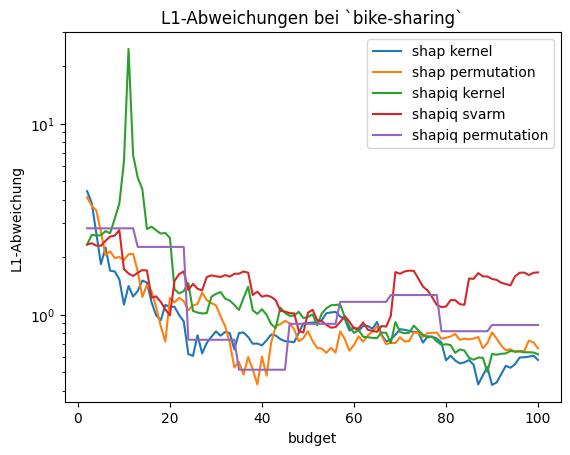

In [8]:
plt.plot(conditional_budget, b_shap_kern_average_l1, label="shap kernel")
plt.plot(conditional_budget, b_shap_perm_average_l1, label="shap permutation")
plt.plot(conditional_budget, b_shapiq_kern_average_l1, label="shapiq kernel")
plt.plot(conditional_budget, b_shapiq_svarm_average_l1, label="shapiq svarm")
plt.plot(conditional_budget, b_shapiq_perm_average_l1, label="shapiq permutation")

plt.yscale("log")
plt.xlabel("budget")
plt.ylabel("L1-Abweichung")
plt.title("L1-Abweichungen bei `bike-sharing`")
plt.legend();

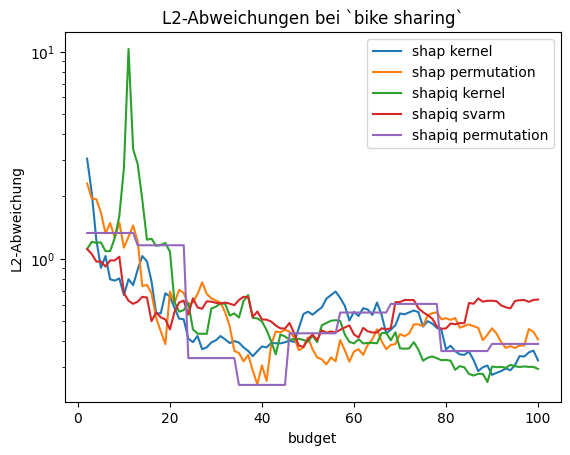

In [9]:
plt.plot(conditional_budget, b_shap_kern_average_l2, label="shap kernel")
plt.plot(conditional_budget, b_shap_perm_average_l2, label="shap permutation")
plt.plot(conditional_budget, b_shapiq_kern_average_l2, label="shapiq kernel")
plt.plot(conditional_budget, b_shapiq_svarm_average_l2, label="shapiq svarm")
plt.plot(conditional_budget, b_shapiq_perm_average_l2, label="shapiq permutation")

plt.yscale("log")
plt.xlabel("budget")
plt.ylabel("L2-Abweichung")
plt.title("L2-Abweichungen bei `bike sharing`")
plt.legend();

## Outcome

While the plots show a lot of artefacts stemming from small test set sizes and artifacts introduced by random sampling, we can still draw some conclusions.

We can observe that the performance of all explainers improves as the budget is improved to 60 to 80 coalitions. From then on, no big difference is visible. So a conditional budget of about 80 coalitions for the imputer can be seen as a sensible amount.

Over different combinations of random state and budgets, the `shapiq` SVARM Explainer seems to be the least accurate, with all others mostly similar. 
A surprising observation is that `shapiq`'s permutation explainer tends to vary a lot in terms of accuracy, although this may, again, be an artifact of our test setup.
